# Config 

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import json
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import os
import time
from pathlib import Path

from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
import sys
import pandas as pd
from tqdm import tqdm

from torchvision import datasets, transforms
import torchvision.utils as vutils
from torch.utils.data import DataLoader
from dataclasses import dataclass
from typing import Tuple, Dict, Optional


DATA_DIR = "./data"
OUTPUT_DIR = "./outputs"

BATCH_SIZE = 128
NUM_WORKERS = 2
LEARNING_RATE = 1e-3
LATENT_DIM = 128
dev_EPOCHS = 10
prod_EPOCHS = 100

# VQ specific variables
code_book_size = 256
hidden_channels = 128
vq_nepoch = 1 #dev_EPOCHS

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
KAGGLE_MODEL_DIR = Path("./Kaggle/Kaggle_run_final")   # change this to your real folder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## data functions

In [12]:
def show_batch(images, n=8, title="Batch"):
    images = images[:n].cpu()
    grid = vutils.make_grid(images, nrow=n, padding=2)
    plt.figure(figsize=(n * 1.5, 2))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray" if images.shape[1] == 1 else None)
    plt.title(title)
    plt.axis("off")
    plt.show()
#==============================================
# data loading and preprocessing
#==============================================

#loades the datasets with the appropriate transformations and returns 
# dataloaders for training and testing, as well as the number of 
# input channels and image size for the specified dataset.
def get_datasets(data_dir="./data", dataset_name="mnist"):
    
    if dataset_name == "mnist":
        
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))])
        
        train_set = datasets.MNIST(root=data_dir, train=True, download=True, transform=transform)
        test_set = datasets.MNIST(root=data_dir, train=False, download=True, transform=transform)
        in_channels, input_size = 1, 28
        

    elif dataset_name == "fashion-mnist":
     
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))])
        train_set = datasets.FashionMNIST(root=data_dir, train=True, download=True, transform=transform)
        test_set = datasets.FashionMNIST(root=data_dir, train=False, download=True, transform=transform)
        in_channels, input_size = 1, 28
        

    elif dataset_name == "cifar10":
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
        train_set = datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform)
        test_set = datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform)
        in_channels, input_size = 3, 32
        

    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    return train_set, test_set, in_channels, input_size

# Wrap the datasets in DataLoaders so training and evaluation can iterate in batches.
def get_dataloaders(data_dir="./data", dataset_name="mnist", batch_size=128, num_workers=2):
    train_set, test_set, in_channels, input_size = get_datasets(data_dir, dataset_name)

    train_loader = DataLoader(
        train_set, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True
    )
    test_loader = DataLoader(
        test_set, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True
    )

    return train_loader, test_loader, in_channels, input_size

In [13]:
mnist_train, mnist_test, mnist_in_channels, mnist_input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="mnist",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
fashion_mnist_train, fashion_mnist_test, fashion_mnist_in_channels, fashion_mnist_input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="fashion-mnist",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
cifar10_train, cifar10_test, cifar10_in_channels, cifar10_input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="cifar10",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

## Model classes

In [14]:
#=======================================================================
# VQ-VAE classes see VQVAE.ipynb for commented code and explanations.
#=======================================================================

@dataclass
class VQLossOutput:
    loss: torch.Tensor
    codebook_loss: torch.Tensor
    commitment_loss: torch.Tensor
    perplexity: torch.Tensor

class EncoderVQ(nn.Module):
    def __init__(self, in_channels=3, hidden_channels=128, latent_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(hidden_channels * 2),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=3, stride=1, padding=1),
        )

    def forward(self, x):
        return self.net(x)

class DecoderVQ(nn.Module):
    def __init__(self, latent_dim=256, hidden_channels=128, out_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_channels * 2),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(hidden_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),  # matches normalized inputs in [-1, 1]
        )

    def forward(self, z):
        return self.net(z)   

class VQVAE(nn.Module):
    def __init__(self, in_channels=3, hidden_channels=128, latent_dim=256, code_book_size=512, commitment_cost=0.25):
        super().__init__()

        self.encoder = EncoderVQ(in_channels=in_channels, hidden_channels=hidden_channels, latent_dim=latent_dim)
        self.vq = VectorQuantizer(code_book_size=code_book_size,embedding_dim=latent_dim,commitment_cost=commitment_cost)
        self.decoder = DecoderVQ(latent_dim=latent_dim, hidden_channels=hidden_channels, out_channels=in_channels)

    def encode(self, x):
        z = self.encoder(x)
        vq_loss, quantized, encoding_indices = self.vq(z)
        return vq_loss, quantized, encoding_indices

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        vq_loss, quantized, encoding_indices = self.encode(x)
        recon = self.decode(quantized)
        return recon, vq_loss, quantized, encoding_indices
    



class VectorQuantizer(nn.Module):
    def __init__(self, code_book_size=512, embedding_dim=256, commitment_cost=0.25):
        super().__init__()
        self.code_book_size = code_book_size
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost
        self.embedding = nn.Embedding(self.code_book_size, embedding_dim)
        self.embedding.weight.data.uniform_(-1 / self.code_book_size, 1 / self.code_book_size)

    def forward(self, z):
        z = z.permute(0, 2, 3, 1).contiguous()
        z_shape = z.shape
        z_flattened = z.view(-1, self.embedding_dim)

        distances = (
            z_flattened.pow(2).sum(dim=1, keepdim=True)
            - 2 * z_flattened @ self.embedding.weight.t()
            + self.embedding.weight.pow(2).sum(dim=1)
        )

        encoding_indices = torch.argmin(distances, dim=1)
        quantized = self.embedding(encoding_indices).view(z_shape)

        commitment_loss = F.mse_loss(quantized.detach(), z)
        codebook_loss = F.mse_loss(quantized, z.detach())
        vq_loss = codebook_loss + self.commitment_cost * commitment_loss

        quantized = z + (quantized - z).detach()
        quantized = quantized.permute(0, 3, 1, 2).contiguous()
        encoding_indices = encoding_indices.view(z_shape[0], z_shape[1], z_shape[2])

        encodings_onehot = F.one_hot(
            encoding_indices.view(-1),
            num_classes=self.code_book_size
        ).float()
        avg_probs = encodings_onehot.mean(dim=0)
        perplexity = torch.exp(-(avg_probs * torch.log(avg_probs + 1e-10)).sum())

        return VQLossOutput(
            loss=vq_loss,
            codebook_loss=codebook_loss,
            commitment_loss=commitment_loss,
            perplexity=perplexity
        ), quantized, encoding_indices


## SSIM and PSNR

In [15]:
# ==============================================================    
#  Functions to measure SSIM an PSNR for reconstructed images
# ==============================================================    

def evaluate_reconstruction_metrics(
    model,
    dataloader,
    device=DEVICE,
    output_mode="prob",   # "prob", "logits", or "tanh"
    use_mixed_precision=False,
    max_batches=None
):
    model.eval()

    psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

    autocast_enabled = use_mixed_precision and torch.cuda.is_available()
    autocast_device = "cuda" if torch.cuda.is_available() else "cpu"

    with torch.no_grad():
        for batch_idx, (x, _) in enumerate(dataloader):
            if max_batches is not None and batch_idx >= max_batches:
                break

            x = x.to(device)

            with torch.amp.autocast(device_type=autocast_device, enabled=autocast_enabled):
                output = model(x)
                x_hat = output[0] if isinstance(output, tuple) else output

            if output_mode == "logits":
                x_hat = torch.sigmoid(x_hat)
            elif output_mode == "tanh":
                x_hat = (x_hat + 1.0) / 2.0
            elif output_mode == "prob":
                pass
            else:
                raise ValueError("output_mode must be 'prob', 'logits', or 'tanh'")

            x_hat = torch.clamp(x_hat, 0.0, 1.0)
            x = torch.clamp(x, 0.0, 1.0)

            psnr_metric.update(x_hat, x)
            ssim_metric.update(x_hat, x)
           
        print("PSNR:", psnr_metric.compute().item())
        print("SSIM:", ssim_metric.compute().item())


# VQ-VAE analysis functions
These are duplicates of the functions from the VAE and VQVAE notebooks

## Graph and results functions

In [16]:
# ==============================================================    
#  See VQVAE.ipynb for commented code and explanations.
# ==============================================================    
def show_vqvae_results(history, test_loader=None, device=None, dataset_name="mnist", images=None, num_images=8):
    model = history["model"]
    model.eval()

    print("Final Metrics")
    print(f"Training time [s]:    {history['Training_time']:.4f}")
    print(f"Final train recon loss:    {history['train_recon_loss'][-1]:.6f}")
    print(f"Final train vq loss:       {history['train_vq_loss'][-1]:.6f}")
    print(f"Final train total loss:    {history['train_total_loss'][-1]:.6f}")
    print(f"Final test recon loss:     {history['test_recon_loss'][-1]:.6f}")
    print(f"Final test vq loss:        {history['test_vq_loss'][-1]:.6f}")
    print(f"Final test total:     {history['test_total_loss'][-1]:.6f}")
    print(f"Final test perplexity:    {history['test_perplexity'][-1]:.6f}")
    print(f"Final used codes:         {history['test_used_codes'][-1]}")
    print(f"Final usage fraction:     {history['test_usage_fraction'][-1]:.6f}")

    if images is None:
        if test_loader is None or device is None:
            return
        images, _ = next(iter(test_loader))

    if device is None:
        raise ValueError("device must be provided when showing reconstructions")

    images = images[:num_images].to(device)

    with torch.no_grad():
        recon_data, vq_out, quantized, encoding_indices = model(images)

    images_vis = denormalize_tensor(images, dataset_name).clamp(0, 1).cpu()
    recon_vis = denormalize_tensor(recon_data, dataset_name).clamp(0, 1).cpu()

    fig, axes = plt.subplots(2, num_images, figsize=(2 * num_images, 4))

    for i in range(num_images):
        original = images_vis[i]
        reconstructed = recon_vis[i]

        if original.shape[0] == 1:
            axes[0, i].imshow(original.squeeze(0), cmap="gray")
            axes[1, i].imshow(reconstructed.squeeze(0), cmap="gray")
        else:
            axes[0, i].imshow(original.permute(1, 2, 0))
            axes[1, i].imshow(reconstructed.permute(1, 2, 0))

        axes[0, i].axis("off")
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Original", fontsize=12)
    axes[1, 0].set_ylabel("Recon", fontsize=12)

    plt.tight_layout()
    plt.show()

    print(f"Last batch VQ loss:   {vq_out.loss.item():.6f}")
    print(f"Last batch perplexity:{vq_out.perplexity.item():.6f}")
    print(f"Quantized shape:      {tuple(quantized.shape)}")
    print(f"Encoding shape:       {tuple(encoding_indices.shape)}")

def denormalize_tensor(x, dataset_name="mnist"):
    if dataset_name in ["mnist", "fashion-mnist"]:
        mean = torch.tensor((0.5,), device=x.device).view(1, 1, 1, 1)
        std = torch.tensor((0.5,), device=x.device).view(1, 1, 1, 1)
    elif dataset_name == "cifar10":
        mean = torch.tensor((0.5, 0.5, 0.5), device=x.device).view(1, 3, 1, 1)
        std = torch.tensor((0.5, 0.5, 0.5), device=x.device).view(1, 3, 1, 1)
    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    return x * std + mean

def moving_average(values, window=25):
    if window is None or window <= 1 or len(values) < window:
        return np.array(values)
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")



def show_vqvae_curves(history, extra_info, smooth_window=25, skip_first_batches=0):
    
    dataset_name = extra_info.get("dataset", "unknown dataset")
    precision_name = extra_info.get("precision", "unknown precision")

    title_prefix = f"{dataset_name} - {precision_name}"

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    # batch-level curves
    train_recon_batch = history["train_recon_loss_batch"][skip_first_batches:]
    train_vq_batch = history["train_vq_loss_batch"][skip_first_batches:]
    train_total_batch = history["train_total_loss_batch"][skip_first_batches:]

    axes[0, 0].plot(moving_average(train_recon_batch, smooth_window), label="Train Recon")
    axes[0, 0].set_title(f"{title_prefix}\nBatch Reconstruction Loss")
    axes[0, 0].set_xlabel("Batch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()

    axes[0, 1].plot(moving_average(train_vq_batch, smooth_window), label="Train VQ")
    axes[0, 1].set_title(f"{title_prefix}\nBatch VQ Loss")
    axes[0, 1].set_xlabel("Batch")
    axes[0, 1].set_ylabel("Loss")
    axes[0, 1].legend()

    axes[0, 2].plot(moving_average(train_total_batch, smooth_window), label="Train Total")
    axes[0, 2].set_title(f"{title_prefix}\nBatch Total Loss")
    axes[0, 2].set_xlabel("Batch")
    axes[0, 2].set_ylabel("Loss")
    axes[0, 2].legend()

    # epoch-level curves
    epochs = np.arange(1, len(history["train_total_loss"]) + 1)

    axes[1, 0].plot(epochs, history["train_recon_loss"], label="Train Recon")
    axes[1, 0].plot(epochs, history["test_recon_loss"], label="Test Recon")
    axes[1, 0].set_title(f"{title_prefix}\nEpoch Reconstruction Loss")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Loss")
    axes[1, 0].legend()

    axes[1, 1].plot(epochs, history["train_vq_loss"], label="Train VQ")
    axes[1, 1].plot(epochs, history["test_vq_loss"], label="Test VQ")
    axes[1, 1].set_title(f"{title_prefix}\nEpoch VQ Loss")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Loss")
    axes[1, 1].legend()

    axes[1, 2].plot(epochs, history["train_total_loss"], label="Train Total")
    axes[1, 2].plot(epochs, history["test_total_loss"], label="Test Total")
    axes[1, 2].set_title(f"{title_prefix}\nEpoch Total Loss")
    axes[1, 2].set_xlabel("Epoch")
    axes[1, 2].set_ylabel("Loss")
    axes[1, 2].legend()

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history["gpu_mem_allocated_mb"], label="Allocated")
    plt.plot(history["gpu_mem_reserved_mb"], label="Reserved")
    plt.plot(history["gpu_mem_peak_mb"], label="Peak allocated")
    plt.xlabel("Epoch")
    plt.ylabel("Memory (MB)")
    plt.title(f"{title_prefix}\nGPU Memory Usage")
    plt.legend()
    plt.show()


def show_vqvae_total_loss(history, extra_info, smooth_window=25, skip_first_batches=0):
    dataset_name = extra_info.get("dataset", "unknown dataset")
    precision_name = extra_info.get("precision", "unknown precision")

    title_prefix = f"{dataset_name} - {precision_name}"

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # batch-level total loss
    train_total_batch = history["train_total_loss_batch"][skip_first_batches:]
    axes[0].plot(moving_average(train_total_batch, smooth_window), label="Train Total")
    axes[0].set_title(f"{title_prefix}\nBatch Total Loss")
    axes[0].set_xlabel("Batch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # epoch-level total loss
    epochs = np.arange(1, len(history["train_total_loss"]) + 1)
    axes[1].plot(epochs, history["train_total_loss"], label="Train Total")
    axes[1].plot(epochs, history["test_total_loss"], label="Test Total")
    axes[1].set_title(f"{title_prefix}\nEpoch Total Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
plt.show()

def print_vqvae_final_metrics(loaded_model, label):
    hist = loaded_model["history"]["model"]
    hist.eval()
    history = loaded_model["history"]

    print(f"Final Metrics {label}")
    print(f"Training time [s]:    {history['Training_time']:.4f}")
    print(f"Final train recon loss:    {history['train_recon_loss'][-1]:.6f}")
    print(f"Final train vq loss:       {history['train_vq_loss'][-1]:.6f}")
    print(f"Final train total loss:    {history['train_total_loss'][-1]:.6f}")
    print(f"Final test recon loss:     {history['test_recon_loss'][-1]:.6f}")
    print(f"Final test vq loss:        {history['test_vq_loss'][-1]:.6f}")
    print(f"Final test total:          {history['test_total_loss'][-1]:.6f}")
    print()

def plot_vqvae_test_total_loss_comparison(history_fp32, history_amp, title="Test Total Loss: FP32 vs Mixed Precision"):
    epochs_fp32 = np.arange(1, len(history_fp32["test_total_loss"]) + 1)
    epochs_amp = np.arange(1, len(history_amp["test_total_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_fp32, history_fp32["test_total_loss"], label="FP32")
    plt.plot(epochs_amp, history_amp["test_total_loss"], label="Mixed Precision")

    plt.xlabel("Epoch")
    plt.ylabel("Test Total Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


        

def show_vqvae_fixed_vs_mixed_results(
    fixed_history,
    mixed_history,
    test_loader=None,
    device=None,
    dataset_name="mnist",
    images=None,
    num_images=8,
    print_metrics=False,
):
    fixed_model = fixed_history["model"]
    mixed_model = mixed_history["model"]

    fixed_model.eval()
    mixed_model.eval()

    if print_metrics:
        print("===== FIXED PRECISION =====")
        print(f"Training time [s]:         {fixed_history['Training_time']:.4f}")
        print(f"Final train recon loss:    {fixed_history['train_recon_loss'][-1]:.6f}")
        print(f"Final train vq loss:       {fixed_history['train_vq_loss'][-1]:.6f}")
        print(f"Final train total loss:    {fixed_history['train_total_loss'][-1]:.6f}")
        print(f"Final test recon loss:     {fixed_history['test_recon_loss'][-1]:.6f}")
        print(f"Final test vq loss:        {fixed_history['test_vq_loss'][-1]:.6f}")
        print(f"Final test total loss:     {fixed_history['test_total_loss'][-1]:.6f}")
        print(f"Final test perplexity:     {fixed_history['test_perplexity'][-1]:.6f}")
        print(f"Final used codes:          {fixed_history['test_used_codes'][-1]}")
        print(f"Final usage fraction:      {fixed_history['test_usage_fraction'][-1]:.6f}")

        print("\n===== MIXED PRECISION =====")
        print(f"Training time [s]:         {mixed_history['Training_time']:.4f}")
        print(f"Final train recon loss:    {mixed_history['train_recon_loss'][-1]:.6f}")
        print(f"Final train vq loss:       {mixed_history['train_vq_loss'][-1]:.6f}")
        print(f"Final train total loss:    {mixed_history['train_total_loss'][-1]:.6f}")
        print(f"Final test recon loss:     {mixed_history['test_recon_loss'][-1]:.6f}")
        print(f"Final test vq loss:        {mixed_history['test_vq_loss'][-1]:.6f}")
        print(f"Final test total loss:     {mixed_history['test_total_loss'][-1]:.6f}")
        print(f"Final test perplexity:     {mixed_history['test_perplexity'][-1]:.6f}")
        print(f"Final used codes:          {mixed_history['test_used_codes'][-1]}")
        print(f"Final usage fraction:      {mixed_history['test_usage_fraction'][-1]:.6f}")

    if images is None:
        if test_loader is None:
            raise ValueError("Provide either images or test_loader")
        images, _ = next(iter(test_loader))

    if device is None:
        raise ValueError("device must be provided")

    images = images[:num_images].to(device)

    with torch.no_grad():
        fixed_recon, fixed_vq_out, fixed_quantized, fixed_encoding_indices = fixed_model(images)
        mixed_recon, mixed_vq_out, mixed_quantized, mixed_encoding_indices = mixed_model(images)

    images_vis = denormalize_tensor(images, dataset_name).clamp(0, 1).cpu()
    fixed_recon_vis = denormalize_tensor(fixed_recon, dataset_name).clamp(0, 1).cpu()
    mixed_recon_vis = denormalize_tensor(mixed_recon, dataset_name).clamp(0, 1).cpu()

    fig, axes = plt.subplots(3, num_images, figsize=(2 * num_images, 6))

    for i in range(num_images):
        original = images_vis[i]
        fixed_img = fixed_recon_vis[i]
        mixed_img = mixed_recon_vis[i]

        if original.shape[0] == 1:
            axes[0, i].imshow(original.squeeze(0), cmap="gray")
            axes[1, i].imshow(fixed_img.squeeze(0), cmap="gray")
            axes[2, i].imshow(mixed_img.squeeze(0), cmap="gray")
        else:
            axes[0, i].imshow(original.permute(1, 2, 0))
            axes[1, i].imshow(fixed_img.permute(1, 2, 0))
            axes[2, i].imshow(mixed_img.permute(1, 2, 0))

        axes[0, i].axis("off")
        axes[1, i].axis("off")
        axes[2, i].axis("off")

    axes[0, 0].set_ylabel("Original", fontsize=12)
    axes[1, 0].set_ylabel("Fixed", fontsize=12)
    axes[2, 0].set_ylabel("Mixed", fontsize=12)

    plt.tight_layout()
    plt.show()


## Load VQVAE

In [17]:


def save_trained_vqvae(
    model,
    optimizer,
    history,
    save_dir="./saved_models",
    run_name="vqvae_run",
    model_config=None,
    best_model_state_dict=None,
    extra_info=None,
):
    save_dir = Path.Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    checkpoint_path = save_dir / f"{run_name}.pt"
    history_path = save_dir / f"{run_name}_history.json"

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "best_model_state_dict": best_model_state_dict,
        "history": history,
        "model_config": model_config if model_config is not None else {},
        "extra_info": extra_info if extra_info is not None else {},
    }

    torch.save(checkpoint, checkpoint_path)

    # remove non-JSON-safe objects from history export
    history_json = {
        k: v for k, v in history.items()
        if k not in ["model", "optimizer"]
    }

    with open(history_path, "w") as f:
        json.dump(
            {
                "history": make_json_safe(history_json),
                "model_config": make_json_safe(model_config if model_config is not None else {}),
                "extra_info": make_json_safe(extra_info if extra_info is not None else {}),
            },
            f,
            indent=2,
        )

    print(f"Saved checkpoint to: {checkpoint_path}")
    print(f"Saved history json to: {history_path}")

    return str(checkpoint_path), str(history_path)


def load_trained_vqvae(
    checkpoint_path,
    model_class,
    device="cpu",
    load_best=False,
):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,   # important fix
    )

    model_config = checkpoint.get("model_config", {})
    model = model_class(**model_config).to(device)

    if load_best and checkpoint.get("best_model_state_dict") is not None:
        model.load_state_dict(checkpoint["best_model_state_dict"])
    else:
        model.load_state_dict(checkpoint["model_state_dict"])

    optimizer_state = checkpoint.get("optimizer_state_dict", None)
    history = checkpoint.get("history", {})
    extra_info = checkpoint.get("extra_info", {})

    return {
        "model": model,
        "optimizer_state_dict": optimizer_state,
        "history": history,
        "model_config": model_config,
        "extra_info": extra_info,
    }




## Fetch VQVAE models

In [18]:
# compatibility aliases for old checkpoint class names
Encoder = EncoderVQ
Decoder = DecoderVQ

vqvae_checkpoint_path = Path(str(KAGGLE_MODEL_DIR / "VQVAE_final"/ "saved_models/VQVAE"))

vqvae_mnist_fp = load_trained_vqvae(
    checkpoint_path=str(vqvae_checkpoint_path/ "MNIST" / "vqvae_mnist_FP.pt"),
    model_class=VQVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)

vqvae_mnist_mp = load_trained_vqvae(
    checkpoint_path=str(vqvae_checkpoint_path/ "MNIST" / "vqvae_mnist_MP.pt"),
    model_class=VQVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)
vqvae_fmnist_fp = load_trained_vqvae(
    checkpoint_path=str(vqvae_checkpoint_path/ "FMNIST" / "vqvae_fashion_mnist_FP.pt"),
    model_class=VQVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)

vqvae_fmnist_mp = load_trained_vqvae(
    checkpoint_path=str(vqvae_checkpoint_path/ "FMNIST" / "vqvae_fashion_mnist_MP.pt"),
    model_class=VQVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)
vqvae_cifar10_fp = load_trained_vqvae(
    checkpoint_path=str(vqvae_checkpoint_path/ "CIFAR" / "vqvae_cifar10_FP.pt"),
    model_class=VQVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)
vqvae_cifar10_mp = load_trained_vqvae(
    checkpoint_path=str(vqvae_checkpoint_path/ "CIFAR" / "vqvae_cifar10_MP.pt"),
    model_class=VQVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)

## Graphs and results

Final Metrics
Training time [s]:    4340.8676
Final train recon loss:    0.004046
Final train vq loss:       0.013860
Final train total loss:    0.017906
Final test recon loss:     0.005289
Final test vq loss:        0.013651
Final test total:     0.018940
Final test perplexity:    96.677170
Final used codes:         216
Final usage fraction:     0.421875


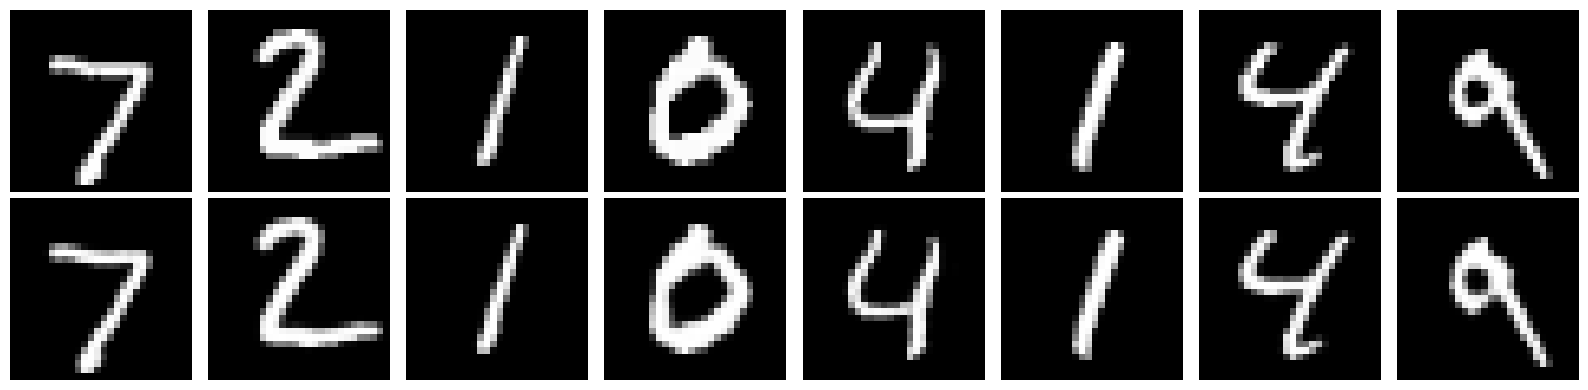

Last batch VQ loss:   0.010863
Last batch perplexity:61.529388
Quantized shape:      (8, 256, 7, 7)
Encoding shape:       (8, 7, 7)
Final Metrics
Training time [s]:    1346.1910
Final train recon loss:    0.003026
Final train vq loss:       0.010741
Final train total loss:    0.013767
Final test recon loss:     0.005184
Final test vq loss:        0.010663
Final test total:     0.015847
Final test perplexity:    94.021797
Final used codes:         224
Final usage fraction:     0.437500


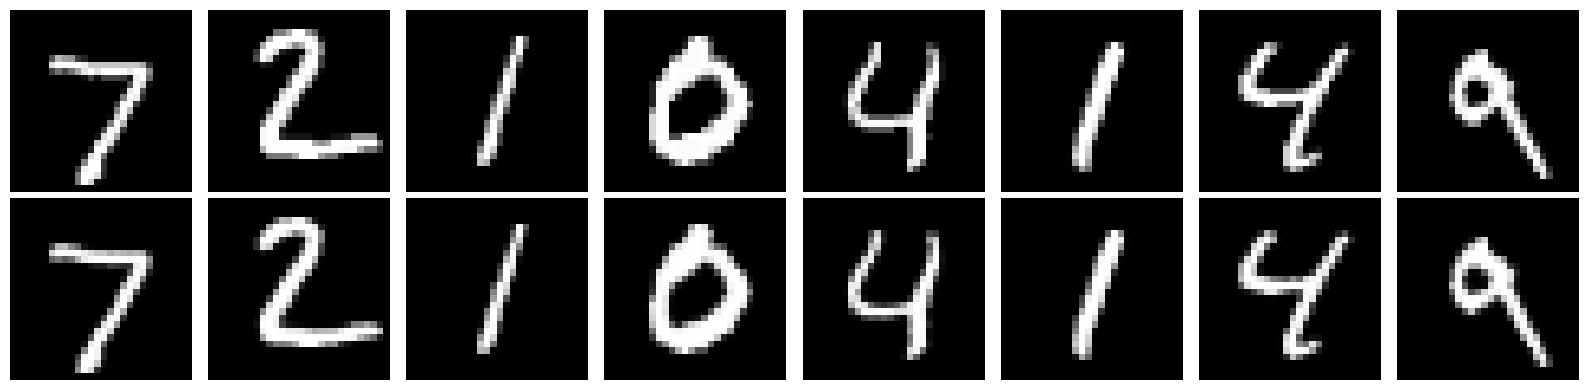

Last batch VQ loss:   0.008349
Last batch perplexity:61.449959
Quantized shape:      (8, 256, 7, 7)
Encoding shape:       (8, 7, 7)


In [10]:
show_vqvae_results(history=vqvae_mnist_fp["history"], test_loader=mnist_test, device=device, dataset_name="mnist", num_images=8)
show_vqvae_results(history=vqvae_mnist_mp["history"], test_loader=mnist_test, device=device, dataset_name="mnist", num_images=8)


Final Metrics
Training time [s]:    4343.9487
Final train recon loss:    0.011678
Final train vq loss:       0.033800
Final train total loss:    0.045477
Final test recon loss:     0.014551
Final test vq loss:        0.034162
Final test total:     0.048713
Final test perplexity:    105.811455
Final used codes:         173
Final usage fraction:     0.337891


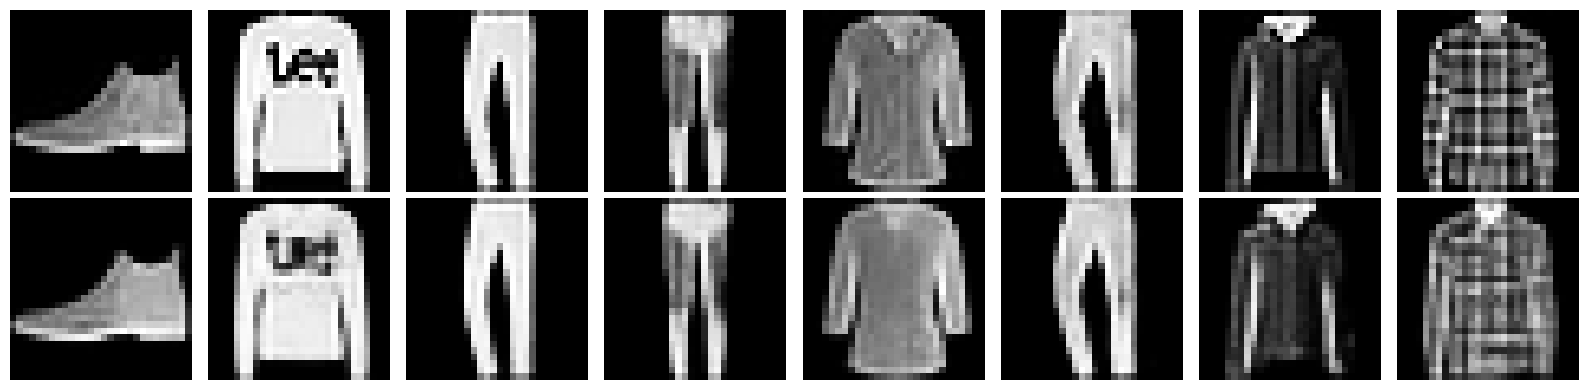

Last batch VQ loss:   0.045709
Last batch perplexity:85.391907
Quantized shape:      (8, 256, 7, 7)
Encoding shape:       (8, 7, 7)
Final Metrics
Training time [s]:    1352.0991
Final train recon loss:    0.009858
Final train vq loss:       0.028807
Final train total loss:    0.038665
Final test recon loss:     0.014745
Final test vq loss:        0.029118
Final test total:     0.043863
Final test perplexity:    114.931099
Final used codes:         183
Final usage fraction:     0.357422


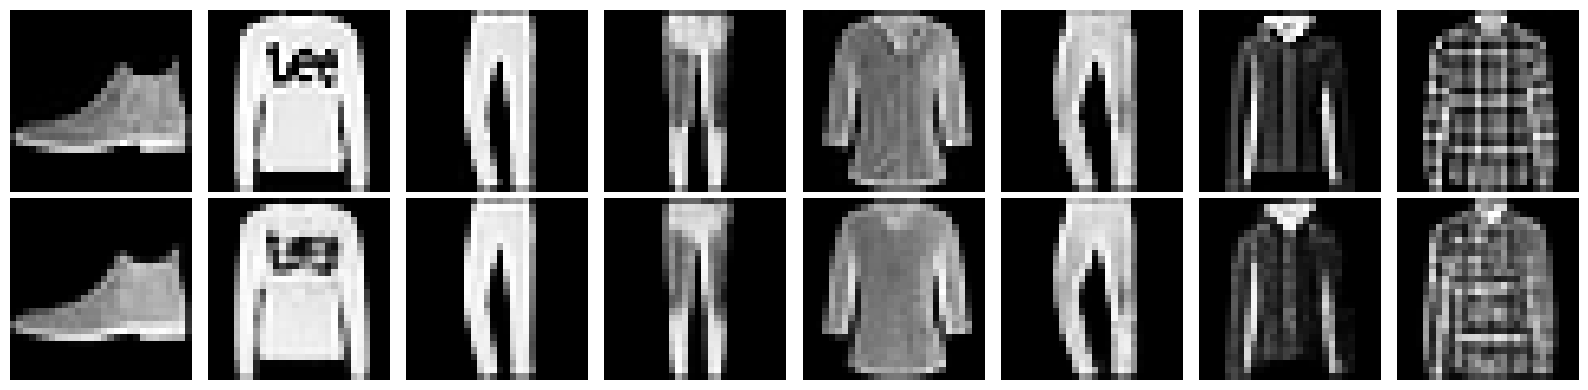

Last batch VQ loss:   0.040790
Last batch perplexity:88.726997
Quantized shape:      (8, 256, 7, 7)
Encoding shape:       (8, 7, 7)


In [19]:
show_vqvae_results(history=vqvae_fmnist_fp["history"], test_loader=fashion_mnist_test, device=device, dataset_name="fashion-mnist", num_images=8)
show_vqvae_results(history=vqvae_fmnist_mp["history"], test_loader=fashion_mnist_test, device=device, dataset_name="fashion-mnist", num_images=8)


Final Metrics
Training time [s]:    4495.7057
Final train recon loss:    0.016780
Final train vq loss:       0.054515
Final train total loss:    0.071295
Final test recon loss:     0.017221
Final test vq loss:        0.054154
Final test total:     0.071375
Final test perplexity:    92.219788
Final used codes:         108
Final usage fraction:     0.210938


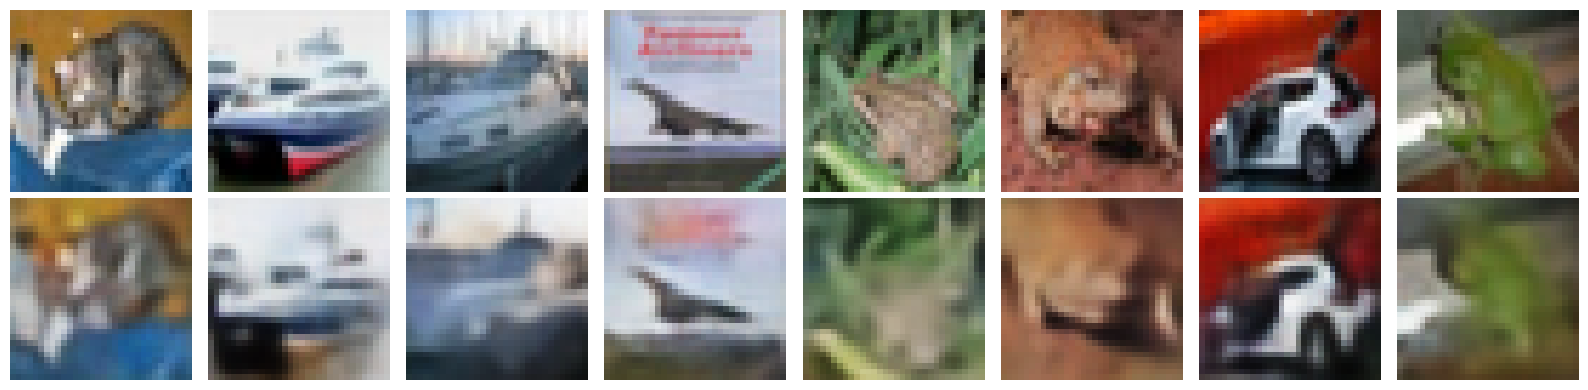

Last batch VQ loss:   0.055385
Last batch perplexity:82.103600
Quantized shape:      (8, 256, 8, 8)
Encoding shape:       (8, 8, 8)
Final Metrics
Training time [s]:    1387.0491
Final train recon loss:    0.015241
Final train vq loss:       0.048919
Final train total loss:    0.064160
Final test recon loss:     0.016631
Final test vq loss:        0.049207
Final test total:     0.065838
Final test perplexity:    111.038078
Final used codes:         129
Final usage fraction:     0.251953


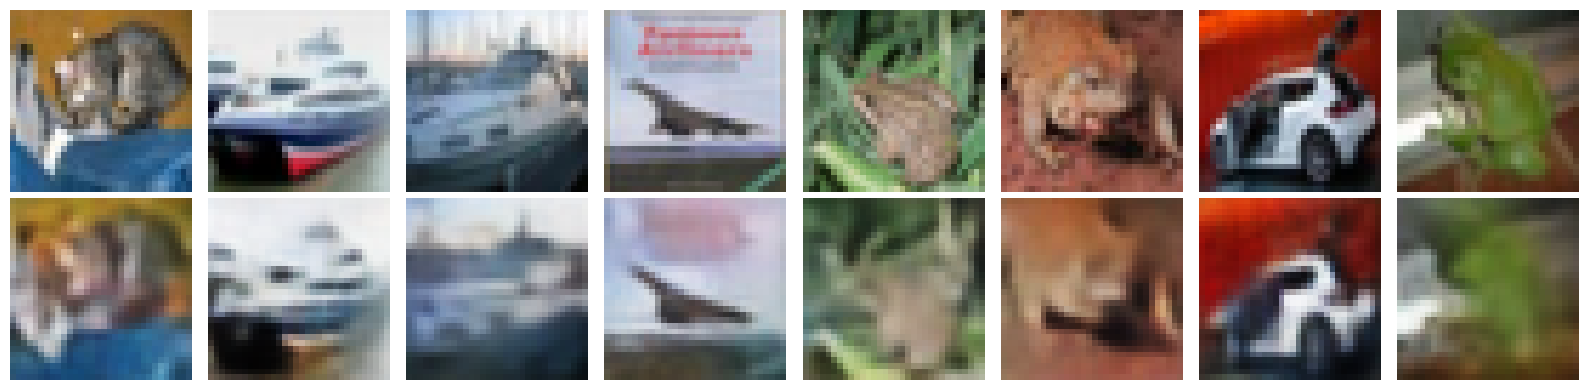

Last batch VQ loss:   0.051998
Last batch perplexity:98.789551
Quantized shape:      (8, 256, 8, 8)
Encoding shape:       (8, 8, 8)


In [20]:
show_vqvae_results(history=vqvae_cifar10_fp["history"], test_loader=cifar10_test, device=device, dataset_name="cifar10", num_images=8)
show_vqvae_results(history=vqvae_cifar10_mp["history"], test_loader=cifar10_test, device=device, dataset_name="cifar10", num_images=8)


In [21]:
print_vqvae_final_metrics(vqvae_mnist_fp, label="MNIST FP32")
print_vqvae_final_metrics(vqvae_mnist_mp, label="MNIST Mixed Precision")
print_vqvae_final_metrics(vqvae_fmnist_fp, label="Fashion MNIST FP32")
print_vqvae_final_metrics(vqvae_fmnist_mp, label="Fashion MNIST Mixed Precision")
print_vqvae_final_metrics(vqvae_cifar10_fp, label="CIFAR-10 FP32")
print_vqvae_final_metrics(vqvae_cifar10_mp, label="CIFAR-10 Mixed Precision")

Final Metrics MNIST FP32
Training time [s]:    4340.8676
Final train recon loss:    0.004046
Final train vq loss:       0.013860
Final train total loss:    0.017906
Final test recon loss:     0.005289
Final test vq loss:        0.013651
Final test total:          0.018940

Final Metrics MNIST Mixed Precision
Training time [s]:    1346.1910
Final train recon loss:    0.003026
Final train vq loss:       0.010741
Final train total loss:    0.013767
Final test recon loss:     0.005184
Final test vq loss:        0.010663
Final test total:          0.015847

Final Metrics Fashion MNIST FP32
Training time [s]:    4343.9487
Final train recon loss:    0.011678
Final train vq loss:       0.033800
Final train total loss:    0.045477
Final test recon loss:     0.014551
Final test vq loss:        0.034162
Final test total:          0.048713

Final Metrics Fashion MNIST Mixed Precision
Training time [s]:    1352.0991
Final train recon loss:    0.009858
Final train vq loss:       0.028807
Final train

In [22]:
print("MNIST FP32:")
evaluate_reconstruction_metrics(model=vqvae_mnist_fp["model"], dataloader=mnist_test,
                                output_mode="tanh", use_mixed_precision=False)

print("MNIST mixed:")
evaluate_reconstruction_metrics(model=vqvae_mnist_mp["model"], dataloader=mnist_test,
                                output_mode="tanh", use_mixed_precision=True)
print("================================================================")

print("Fashion MNIST FP32:")
evaluate_reconstruction_metrics(model=vqvae_fmnist_fp["model"], dataloader=fashion_mnist_test,
                                output_mode="tanh", use_mixed_precision=False)
print("Fashion MNIST mixed:")
evaluate_reconstruction_metrics(model=vqvae_fmnist_mp["model"], dataloader=fashion_mnist_test,
                                output_mode="tanh", use_mixed_precision=True)
print("================================================================")
print("CIFAR-10 FP32:")
evaluate_reconstruction_metrics(model=vqvae_cifar10_fp["model"], dataloader=cifar10_test,
                                output_mode="tanh", use_mixed_precision=False)
print("CIFAR-10 mixed:")
evaluate_reconstruction_metrics(model=vqvae_cifar10_mp["model"], dataloader=cifar10_test,
                                output_mode="tanh", use_mixed_precision=True)

MNIST FP32:
PSNR: 20.093341827392578
SSIM: 0.9059135913848877
MNIST mixed:
PSNR: 20.081016540527344
SSIM: 0.9095859527587891
Fashion MNIST FP32:
PSNR: 13.822312355041504
SSIM: 0.6189830303192139
Fashion MNIST mixed:
PSNR: 13.764363288879395
SSIM: 0.6260140538215637
CIFAR-10 FP32:
PSNR: 9.7783784866333
SSIM: 0.26911938190460205
CIFAR-10 mixed:
PSNR: 9.775528907775879
SSIM: 0.2727664113044739


In [23]:
x, _ = next(iter(cifar10_test))
x = x.to(device)

with torch.no_grad():
    out = vae_cifar10_fp["model"](x)
    x_hat = out[0] if isinstance(out, tuple) else out

print("x_hat min:", x_hat.min().item())
print("x_hat max:", x_hat.max().item())

NameError: name 'vae_cifar10_fp' is not defined

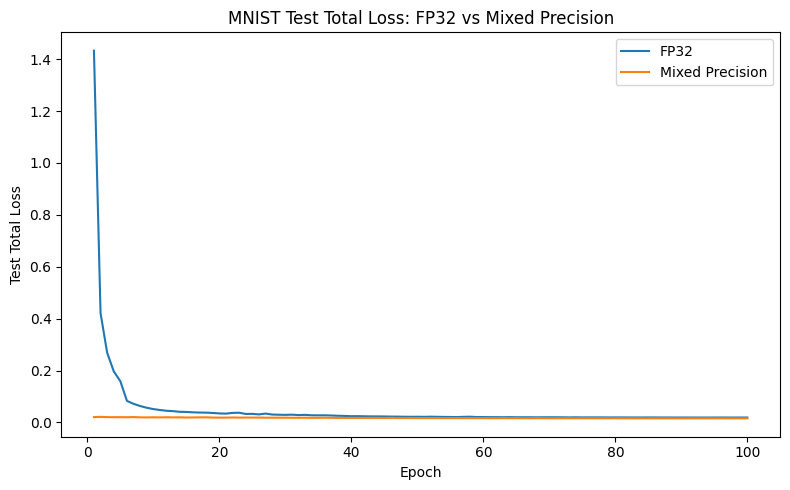

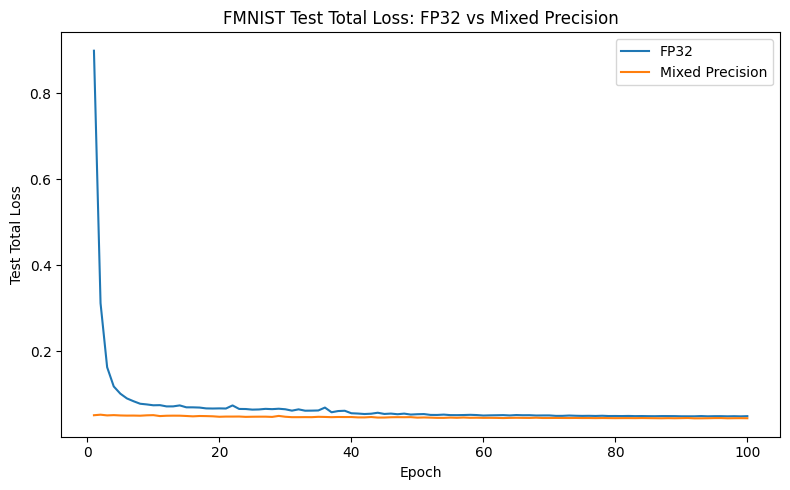

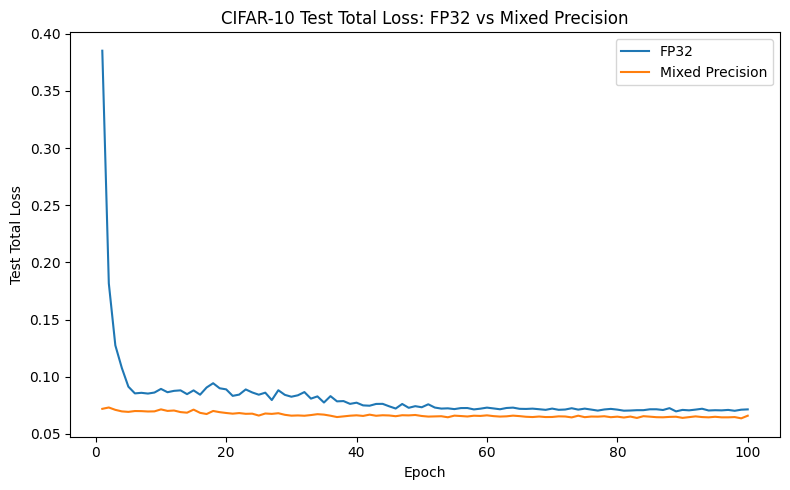

In [ ]:
plot_vqvae_test_total_loss_comparison(history_fp32=vqvae_mnist_fp["history"], 
                                      history_amp=vqvae_mnist_mp["history"],
                                      title="MNIST Test Total Loss: FP32 vs Mixed Precision")

plot_vqvae_test_total_loss_comparison(history_fp32=vqvae_fmnist_fp["history"], 
                                      history_amp=vqvae_fmnist_mp["history"],
                                      title="FMNIST Test Total Loss: FP32 vs Mixed Precision")

plot_vqvae_test_total_loss_comparison(history_fp32=vqvae_cifar10_fp["history"], 
                                      history_amp=vqvae_cifar10_mp["history"],
                                      title="CIFAR-10 Test Total Loss: FP32 vs Mixed Precision")

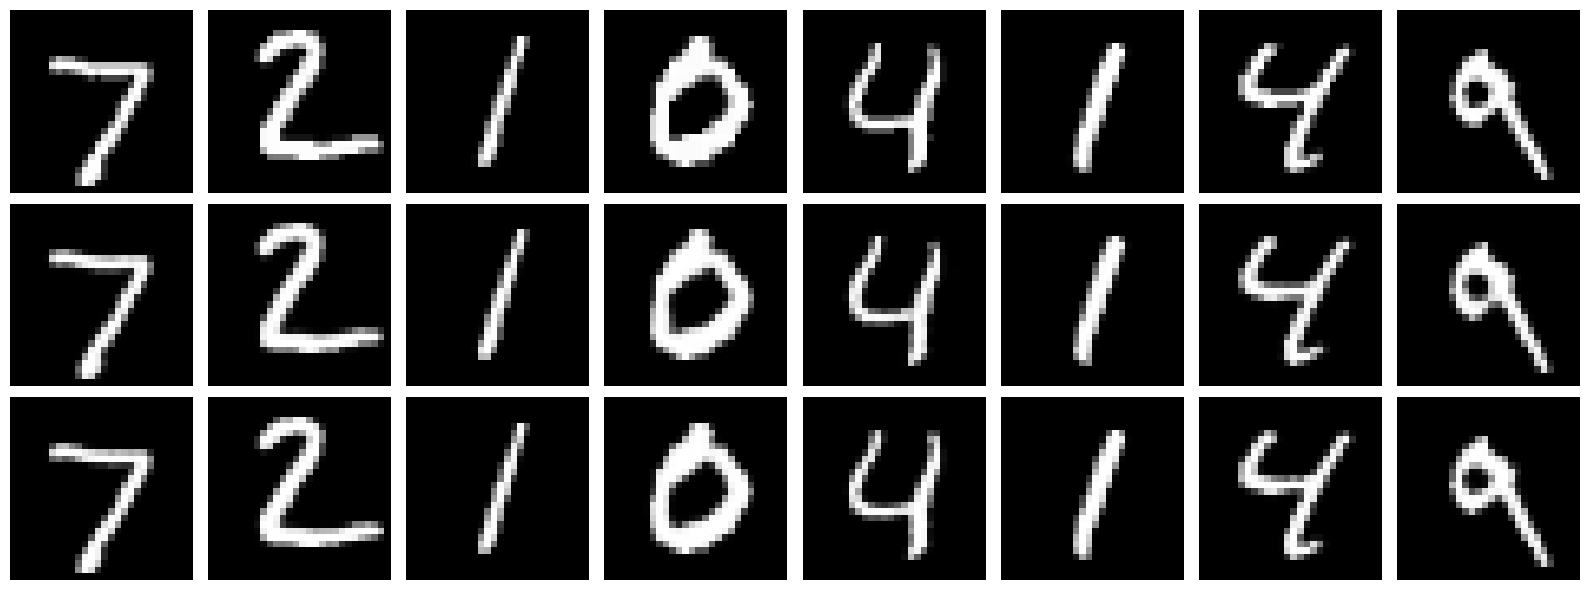

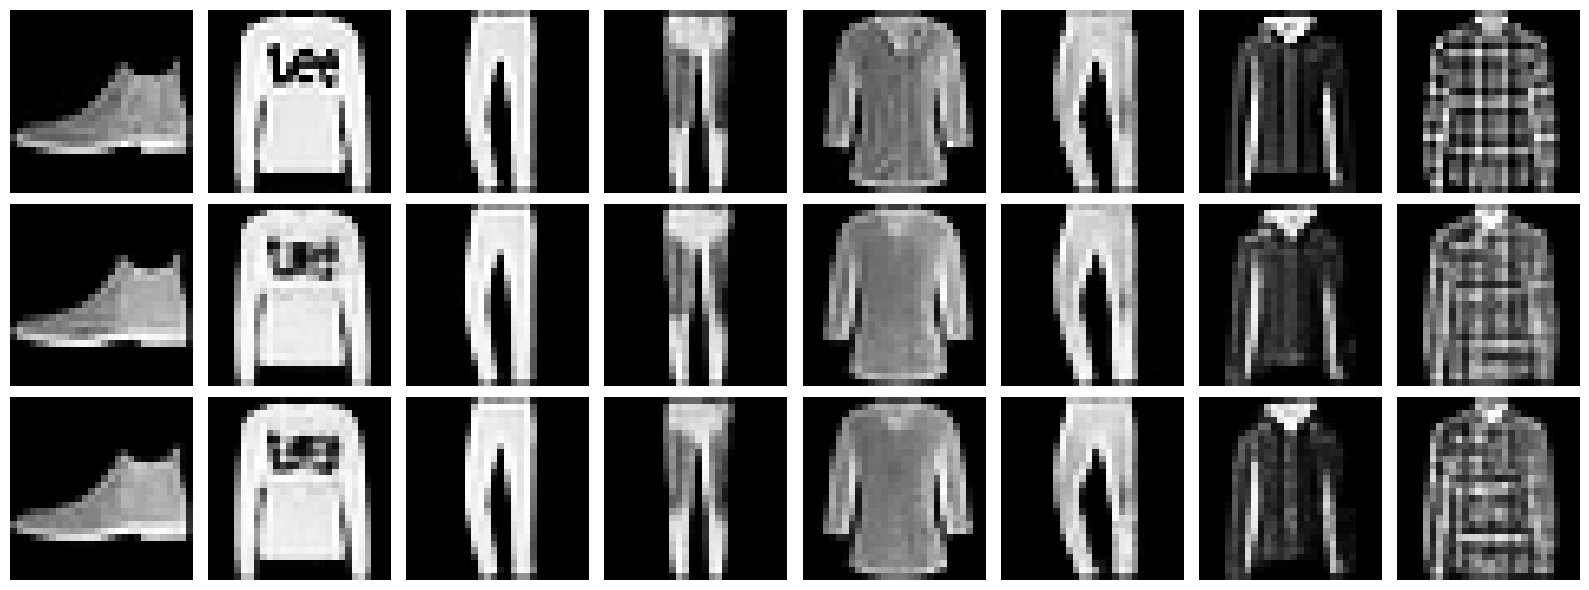

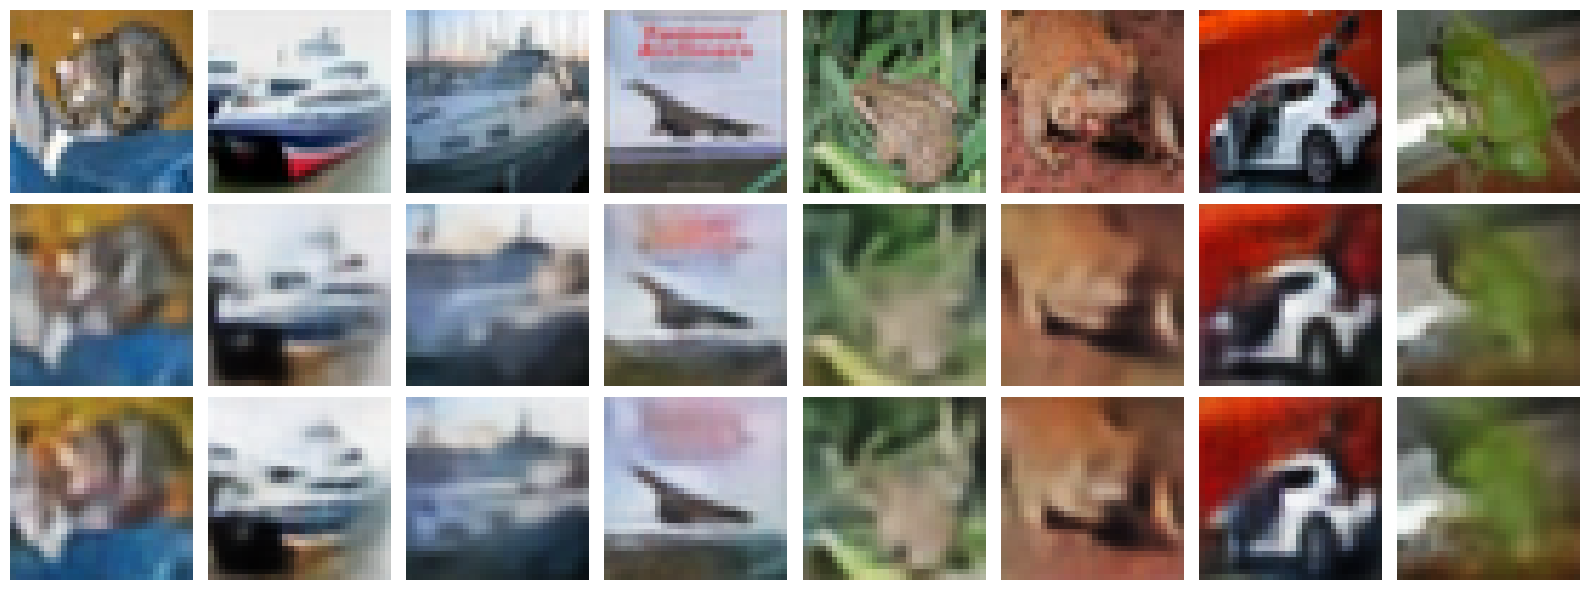

In [ ]:
show_vqvae_fixed_vs_mixed_results(
    fixed_history=vqvae_mnist_fp,
    mixed_history=vqvae_mnist_mp,
    test_loader=mnist_test,
    device=device,
    dataset_name="mnist",
    num_images=8
)
show_vqvae_fixed_vs_mixed_results(
    fixed_history=vqvae_fmnist_fp,
    mixed_history=vqvae_fmnist_mp,
    test_loader=fashion_mnist_test,
    device=device,
    dataset_name="fashion-mnist",
    num_images=8
)
show_vqvae_fixed_vs_mixed_results(
    fixed_history=vqvae_cifar10_fp,
    mixed_history=vqvae_cifar10_mp,
    test_loader=cifar10_test,
    device=device,
    dataset_name="cifar10",
    num_images=8
)